In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


In [5]:
kv = bspline.make_knots(10,0,64,4,mult=2)
nodes = np.array([0,32,34,36,38,40,64],'d')

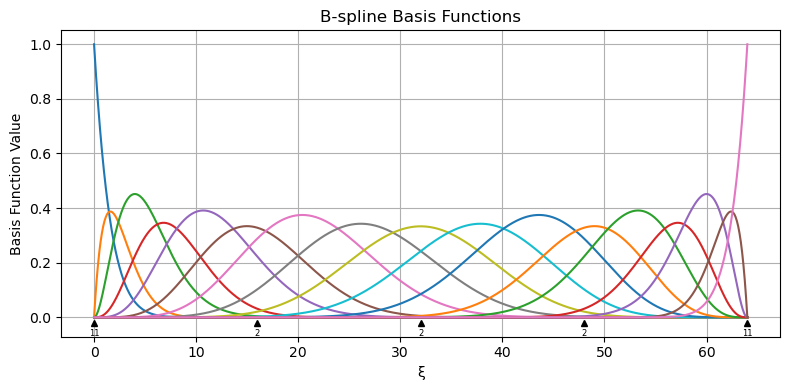

In [6]:
kv.plot(knots=1)

In [49]:
C = bspline.collocation(kv,nodes)

In [50]:
print(len(nodes),kv.numdofs,len(nodes)<=kv.numdofs)

7 19 True


In [51]:
for i in range(kv.numdofs):
    a,b = kv.support(i)
    count = sum((a - 1e-14 <= nodes) & (nodes  < b - 1e-14  ))
    print(count,kv.p+1,count<=kv.p+1)

1 5 True
1 5 True
1 5 True
1 5 True
1 5 True
0 5 True
0 5 True
0 5 True
4 5 True
4 5 True
5 5 True
5 5 True
5 5 True
1 5 True
1 5 True
0 5 True
0 5 True
0 5 True
0 5 True


In [52]:
C.shape[0]==np.linalg.matrix_rank(C.toarray())

np.True_

In [53]:
C.toarray()

array([[1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.50000e-01, 5.00000e-01, 2.50000e-01, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 7.91016e-02, 3.69141e-01, 5.25391e-01, 2.53906e-02, 9.76562e-04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.56250e-02, 1.56250e-01, 6.56250e-01, 1.56250e-01, 1.56250e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.0

In [25]:
C.shape[0]-np.linalg.matrix_rank(C.toarray())

2